In [1]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [4]:
fuzzy_scale = {
    "N": (0.00, 0.00, 0.00),
    "L": (0.00, 0.25, 0.50),
    "M": (0.25, 0.50, 0.75),
    "H": (0.50, 0.75, 1.00),
    "VH": (0.75, 1.00, 1.00)
}

In [ ]:
# ============================================================
# FUZZY DEMATEL: GENERATE AGGREGATED DIRECT-RELATION MATRIX
# Input: expert_responses.xlsx
# Output: direct_relation_matrix.xlsx
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# STEP 1: FILE SETTINGS
# ------------------------------------------------------------

input_file = "expert_responses.xlsx"
output_file = "direct_relation_matrix.xlsx"

if not os.path.exists(input_file):
    raise FileNotFoundError(
        f"Input file not found: {os.path.abspath(input_file)}"
    )

# ------------------------------------------------------------
# STEP 2: FUZZY SCALE
# ------------------------------------------------------------

FUZZY_SCALE = {
    "N":  (0.00, 0.00, 0.00),
    "L":  (0.00, 0.25, 0.50),
    "M":  (0.25, 0.50, 0.75),
    "H":  (0.50, 0.75, 1.00),
    "VH": (0.75, 1.00, 1.00)
}

# Accepted abbreviations and full labels
LABEL_MAP = {
    "N": "N",
    "NO": "N",
    "NO INFLUENCE": "N",

    "L": "L",
    "LOW": "L",
    "LOW INFLUENCE": "L",

    "M": "M",
    "MEDIUM": "M",
    "MEDIUM INFLUENCE": "M",

    "H": "H",
    "HIGH": "H",
    "HIGH INFLUENCE": "H",

    "VH": "VH",
    "VERY HIGH": "VH",
    "VERY HIGH INFLUENCE": "VH"
}

# ------------------------------------------------------------
# STEP 3: READ EXPERT SHEETS
# ------------------------------------------------------------

xls = pd.ExcelFile(input_file)

expert_sheets = [
    sheet for sheet in xls.sheet_names
    if sheet.startswith("E") and sheet[1:].isdigit()
]

expert_sheets = sorted(
    expert_sheets,
    key=lambda name: int(name[1:])
)

if not expert_sheets:
    raise ValueError(
        "No expert sheets found. Expected sheet names such as E1, E2, ..., E15."
    )

expert_matrices = []

for sheet in expert_sheets:

    df = pd.read_excel(
        input_file,
        sheet_name=sheet,
        index_col=0
    )

    df.index = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()

    if df.index.has_duplicates or df.columns.has_duplicates:
        raise ValueError(f"Duplicate factor labels in sheet {sheet}.")

    if list(df.index) != list(df.columns):
        raise ValueError(
            f"Row and column labels do not match in sheet {sheet}."
        )

    expert_matrices.append(df)

factors = expert_matrices[0].index.tolist()
n = len(factors)

# Validate consistent dimensions and ordering
for sheet, df in zip(expert_sheets, expert_matrices):

    if df.shape != (n, n):
        raise ValueError(
            f"Incorrect matrix dimensions in sheet {sheet}."
        )

    if list(df.index) != factors or list(df.columns) != factors:
        raise ValueError(
            f"Factor labels or ordering differ in sheet {sheet}."
        )

print(f"Expert sheets found: {len(expert_sheets)}")
print(f"Factors found: {n}")

# ------------------------------------------------------------
# STEP 4: CONVERT RESPONSES INTO FUZZY NUMBERS
# ------------------------------------------------------------

fuzzy_matrices = []

for sheet, df in zip(expert_sheets, expert_matrices):

    fuzzy = np.zeros((n, n, 3), dtype=float)

    for i in range(n):
        for j in range(n):

            # Self-influence is set to zero
            if i == j:
                fuzzy[i, j] = (0.0, 0.0, 0.0)
                continue

            raw_response = df.iloc[i, j]

            if pd.isna(raw_response):
                raise ValueError(
                    f"Missing response in {sheet}: "
                    f"{factors[i]} -> {factors[j]}"
                )

            response = str(raw_response).strip().upper()

            # Support cells containing labels such as:
            # "L", "Low influence", or "L (0, 0.25, 0.50)"
            matched_term = None

            if response in LABEL_MAP:
                matched_term = LABEL_MAP[response]
            else:
                # Normalize line breaks and common separators
                normalized = (
                    response.replace("\n", " ")
                    .replace("_", " ")
                    .replace("-", " ")
                )

                normalized = " ".join(normalized.split())

                # Prefer longer matches first
                for label in sorted(
                    LABEL_MAP.keys(),
                    key=len,
                    reverse=True
                ):
                    if normalized.startswith(label):
                        remainder = normalized[len(label):]

                        # Avoid matching N inside unrelated words
                        if (
                            remainder == ""
                            or remainder[0] in " ([{:"
                        ):
                            matched_term = LABEL_MAP[label]
                            break

            if matched_term is None:
                raise ValueError(
                    f"Unrecognized response in sheet {sheet}, "
                    f"{factors[i]} -> {factors[j]}: "
                    f"{raw_response!r}. "
                    "Use N, L, M, H, VH or their full labels."
                )

            fuzzy[i, j] = FUZZY_SCALE[matched_term]

    fuzzy_matrices.append(fuzzy)

# ------------------------------------------------------------
# STEP 5: AGGREGATE FUZZY NUMBERS ACROSS EXPERTS
# ------------------------------------------------------------

# Arithmetic mean of each triangular component
aggregated_fuzzy = np.mean(
    np.stack(fuzzy_matrices, axis=0),
    axis=0
)

# ------------------------------------------------------------
# STEP 6: CENTROID DEFUZZIFICATION
# ------------------------------------------------------------

# z_ij = (l + m + u) / 3
direct_matrix = aggregated_fuzzy.mean(axis=2)

# Ensure diagonal is exactly zero
np.fill_diagonal(direct_matrix, 0.0)

direct_df = pd.DataFrame(
    direct_matrix,
    index=factors,
    columns=factors
)

# ------------------------------------------------------------
# STEP 7: EXPORT RESULTS
# ------------------------------------------------------------

with pd.ExcelWriter(
    output_file,
    engine="openpyxl",
    mode="w"
) as writer:

    direct_df.to_excel(
        writer,
        sheet_name="Direct_Relation_Matrix"
    )

    # Export aggregated fuzzy components
    for k, component in enumerate(["Lower", "Middle", "Upper"]):

        component_df = pd.DataFrame(
            aggregated_fuzzy[:, :, k],
            index=factors,
            columns=factors
        )

        component_df.to_excel(
            writer,
            sheet_name=f"Fuzzy_{component}"
        )

    # Export expert count and scale for documentation
    scale_df = pd.DataFrame([
        {
            "Category": label,
            "Lower": values[0],
            "Middle": values[1],
            "Upper": values[2]
        }
        for label, values in FUZZY_SCALE.items()
    ])

    scale_df.to_excel(
        writer,
        sheet_name="Fuzzy_Scale",
        index=False
    )

print("\n" + "=" * 55)
print("DIRECT-RELATION MATRIX GENERATED")
print("=" * 55)
print(f"Experts processed: {len(expert_sheets)}")
print(f"Factors: {n}")
print("\nAggregated direct-relation matrix:")
print(direct_df.round(4))
print(f"\nOutput file: {os.path.abspath(output_file)}")

Expert sheets found: 15
Factors found: 15

DIRECT-RELATION MATRIX GENERATED
Experts processed: 15
Factors: 15

Aggregated direct-relation matrix:
         F1      F2      F3      F4      F5      F6      F7      F8      F9  \
F1   0.0000  0.3167  0.2611  0.2667  0.2111  0.1833  0.2333  0.3944  0.3722   
F2   0.1667  0.0000  0.2444  0.2611  0.2833  0.3333  0.2889  0.2833  0.3500   
F3   0.2278  0.1111  0.0000  0.3500  0.4111  0.3389  0.2889  0.1944  0.3889   
F4   0.2722  0.1722  0.2278  0.0000  0.2389  0.4056  0.4333  0.4333  0.4667   
F5   0.1722  0.1333  0.2778  0.2000  0.0000  0.2722  0.2444  0.3722  0.2333   
F6   0.2333  0.2389  0.0611  0.1722  0.1667  0.0000  0.3444  0.2278  0.2056   
F7   0.0833  0.2278  0.2444  0.2278  0.3389  0.2389  0.0000  0.2556  0.2000   
F8   0.1444  0.1778  0.2667  0.1722  0.1889  0.2111  0.2556  0.0000  0.4222   
F9   0.2833  0.2944  0.1556  0.1389  0.2222  0.2444  0.4167  0.3889  0.0000   
F10  0.1944  0.2333  0.2833  0.2389  0.4444  0.4167  0.3111  0.3

Number of factors: 15
Input matrix loaded successfully.

Normalization factor: 4.474

NORMALIZED DIRECT-RELATION MATRIX
         F1      F2      F3      F4      F5      F6      F7      F8      F9  \
F1   0.0000  0.0704  0.0586  0.0595  0.0472  0.0407  0.0519  0.0881  0.0831   
F2   0.0371  0.0000  0.0552  0.0583  0.0630  0.0749  0.0646  0.0639  0.0780   
F3   0.0514  0.0250  0.0000  0.0780  0.0914  0.0762  0.0644  0.0431  0.0865   
F4   0.0603  0.0387  0.0510  0.0000  0.0532  0.0912  0.0968  0.0966  0.1042   
F5   0.0389  0.0304  0.0624  0.0443  0.0000  0.0610  0.0548  0.0829  0.0516   
F6   0.0525  0.0530  0.0141  0.0387  0.0376  0.0000  0.0764  0.0505  0.0454   
F7   0.0192  0.0510  0.0543  0.0514  0.0758  0.0539  0.0000  0.0572  0.0445   
F8   0.0320  0.0391  0.0592  0.0380  0.0420  0.0476  0.0570  0.0000  0.0941   
F9   0.0630  0.0664  0.0342  0.0308  0.0501  0.0550  0.0937  0.0867  0.0000   
F10  0.0434  0.0527  0.0637  0.0530  0.0999  0.0930  0.0693  0.0738  0.0726   
F11  0.0523

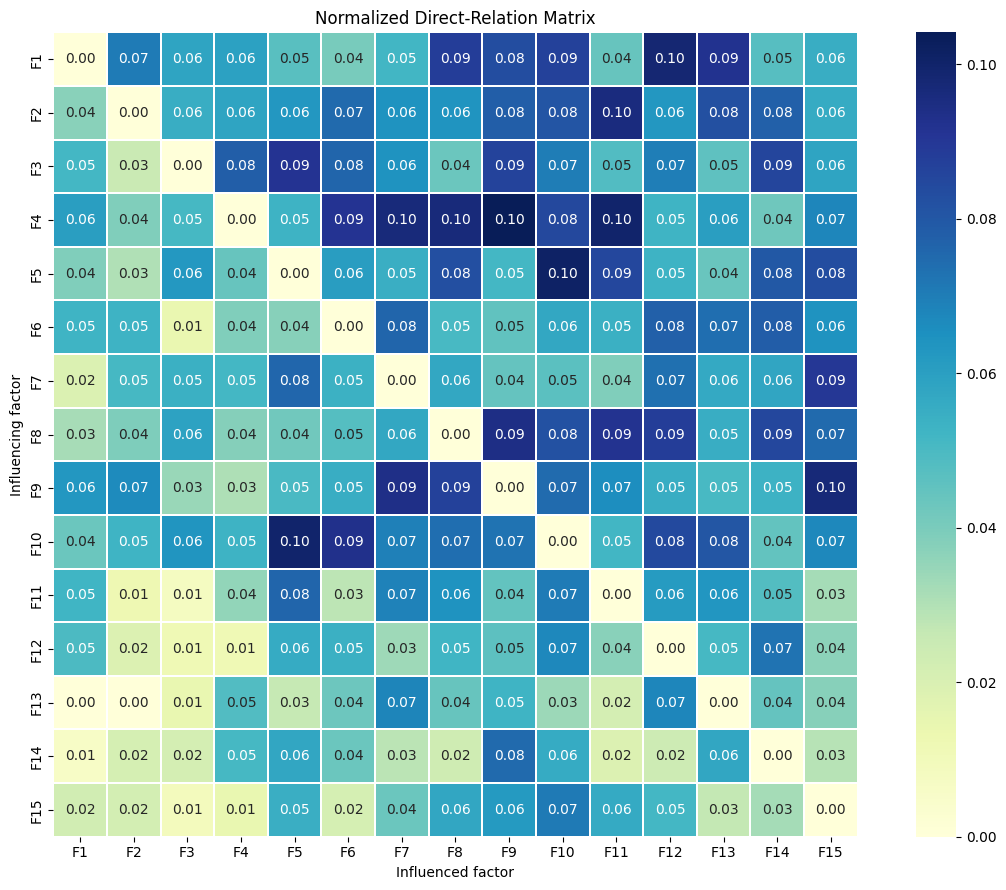

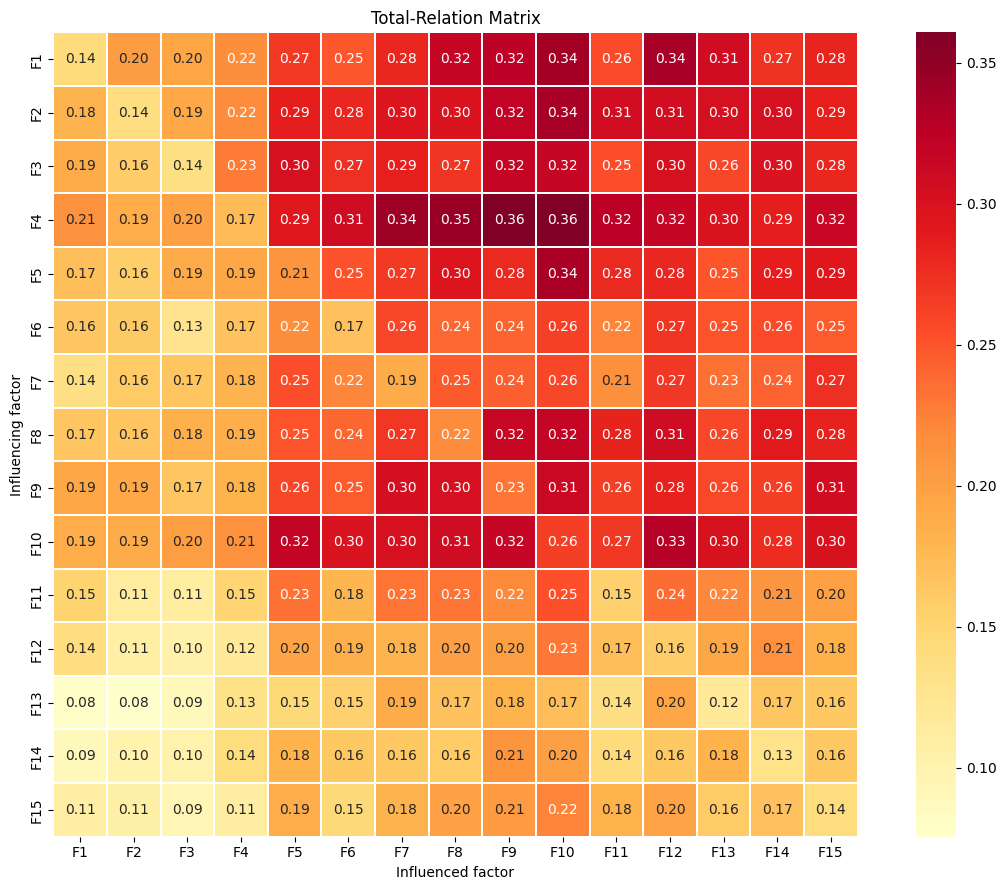

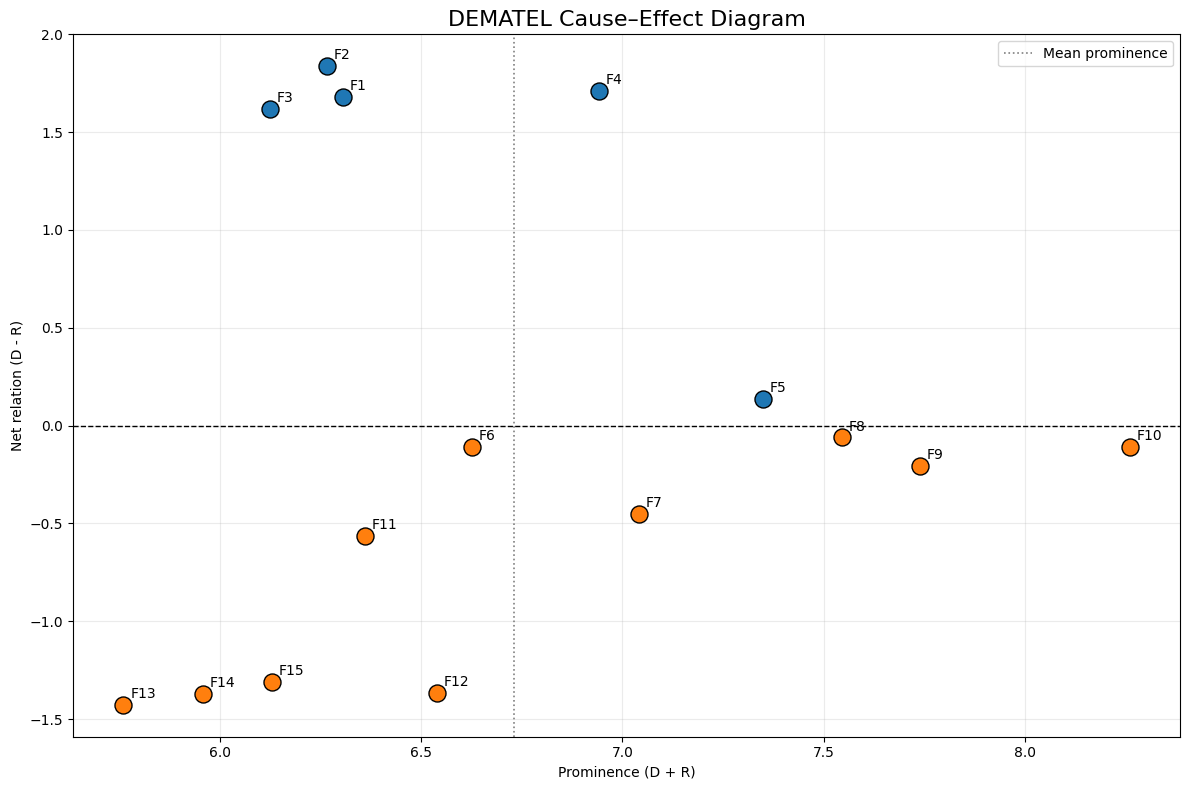

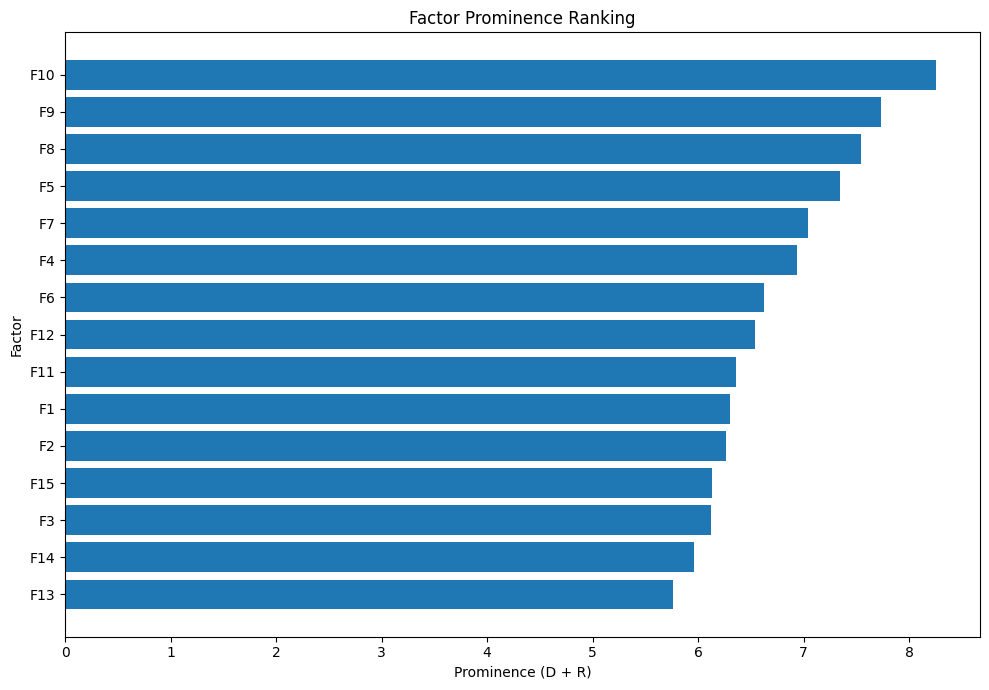


DEMATEL ANALYSIS COMPLETED

Highest-prominence factor:
F10 with prominence = 8.2595

Cause / driver factors:
['F5', 'F4', 'F1', 'F2', 'F3']

Effect / receiver factors:
['F10', 'F9', 'F8', 'F7', 'F6', 'F12', 'F11', 'F15', 'F14', 'F13']

Output folder: DEMATEL_Results
Files generated:
- DEMATEL_Complete_Results.xlsx
- Normalized_Matrix_Heatmap.png
- Total_Relation_Matrix_Heatmap.png
- Cause_Effect_Diagram.png
- Prominence_Ranking.png


In [7]:

# ============================================================
# DEMATEL ANALYSIS: 15 FACTORS
# Input: direct_relation_matrix.xlsx
# Output: Excel workbook, heatmaps, cause-effect diagram
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# STEP 1: FILE SETTINGS
# ------------------------------------------------------------

INPUT_FILE = "direct_relation_matrix.xlsx"
OUTPUT_DIR = "DEMATEL_Results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# STEP 2: READ AND VALIDATE THE DIRECT-RELATION MATRIX
# ------------------------------------------------------------

df = pd.read_excel(INPUT_FILE, index_col=0)

# Clean labels
df.index = df.index.astype(str).str.strip()
df.columns = df.columns.astype(str).str.strip()

# Ensure row and column labels match
if list(df.index) != list(df.columns):
    raise ValueError(
        "Row and column labels must match in the same order."
    )

# Convert to numeric values
df = df.apply(pd.to_numeric, errors="raise")

X = df.to_numpy(dtype=float)
factors = df.index.tolist()

# Basic checks
if X.shape[0] != X.shape[1]:
    raise ValueError("The direct-relation matrix must be square.")

if not np.isfinite(X).all():
    raise ValueError("The matrix contains missing or infinite values.")

if np.any(X < 0):
    raise ValueError("Matrix values cannot be negative.")

if not np.allclose(np.diag(X), 0):
    raise ValueError(
        "Diagonal values must be zero. Check the input matrix."
    )

n = X.shape[0]

print(f"Number of factors: {n}")
print("Input matrix loaded successfully.")

# ------------------------------------------------------------
# STEP 3: NORMALIZE THE DIRECT-RELATION MATRIX
# ------------------------------------------------------------
# Standard DEMATEL normalization:
# N = X / max(maximum row sum, maximum column sum)

row_sums = X.sum(axis=1)
col_sums = X.sum(axis=0)

s = max(row_sums.max(), col_sums.max())

if s <= 0:
    raise ValueError("Normalization factor must be positive.")

N = X / s

normalized_df = pd.DataFrame(
    N, index=factors, columns=factors
)

print("\nNormalization factor:", round(s, 6))
print("\nNORMALIZED DIRECT-RELATION MATRIX")
print(normalized_df.round(4))

# ------------------------------------------------------------
# STEP 4: CALCULATE THE TOTAL-RELATION MATRIX
# ------------------------------------------------------------
# T = N (I - N)^(-1)

I = np.eye(n)

if np.linalg.cond(I - N) > 1e12:
    raise ValueError(
        "I - N is numerically ill-conditioned; "
        "check the normalization and input matrix."
    )

T = N @ np.linalg.solve(I - N, I)

total_df = pd.DataFrame(
    T, index=factors, columns=factors
)

print("\nTOTAL-RELATION MATRIX")
print(total_df.round(4))

# ------------------------------------------------------------
# STEP 5: CALCULATE D, R, PROMINENCE, AND NET RELATION
# ------------------------------------------------------------

D = T.sum(axis=1)  # Total influence dispatched
R = T.sum(axis=0)  # Total influence received

prominence = D + R
relation = D - R

results = pd.DataFrame({
    "Factor": factors,
    "D_Dispatched": D,
    "R_Received": R,
    "Prominence_D+R": prominence,
    "NetRelation_D-R": relation
})

# Rank 1 = highest prominence
results["Prominence_Rank"] = (
    results["Prominence_D+R"]
    .rank(method="min", ascending=False)
    .astype(int)
)

# Positive net relation = cause/driver
# Negative net relation = effect/receiver
results["Cause_Effect"] = np.where(
    relation > 1e-10,
    "Cause / Driver",
    np.where(
        relation < -1e-10,
        "Effect / Receiver",
        "Approximately Neutral"
    )
)

results = results.sort_values(
    "Prominence_Rank"
).reset_index(drop=True)

print("\nDEMATEL RESULTS — RANKED BY PROMINENCE")
print(results.round(4).to_string(index=False))

# ------------------------------------------------------------
# STEP 6: EXPORT ALL NUMERICAL RESULTS TO EXCEL
# ------------------------------------------------------------

output_excel = os.path.join(
    OUTPUT_DIR, "DEMATEL_Complete_Results.xlsx"
)

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:

    df.to_excel(writer, sheet_name="Direct_Matrix")
    normalized_df.to_excel(
        writer, sheet_name="Normalized_Matrix"
    )
    total_df.to_excel(
        writer, sheet_name="Total_Relation_Matrix"
    )
    results.to_excel(
        writer, sheet_name="Prominence_Ranking", index=False
    )

    # Export a separate table in original factor order
    results_ordered = (
        results.set_index("Factor")
        .reindex(factors)
        .reset_index()
    )
    results_ordered.to_excel(
        writer, sheet_name="Results_Factor_Order", index=False
    )

print("\nExcel results saved:", output_excel)

# ------------------------------------------------------------
# STEP 7: NORMALIZED MATRIX HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 9))

sns.heatmap(
    normalized_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.3,
    square=True
)

plt.title("Normalized Direct-Relation Matrix")
plt.xlabel("Influenced factor")
plt.ylabel("Influencing factor")
plt.tight_layout()

heatmap_normalized = os.path.join(
    OUTPUT_DIR, "Normalized_Matrix_Heatmap.png"
)

plt.savefig(
    heatmap_normalized, dpi=300, bbox_inches="tight"
)
plt.show()
plt.close()

# ------------------------------------------------------------
# STEP 8: TOTAL-RELATION MATRIX HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(12, 9))

sns.heatmap(
    total_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.3,
    square=True
)

plt.title("Total-Relation Matrix")
plt.xlabel("Influenced factor")
plt.ylabel("Influencing factor")
plt.tight_layout()

heatmap_total = os.path.join(
    OUTPUT_DIR, "Total_Relation_Matrix_Heatmap.png"
)

plt.savefig(
    heatmap_total, dpi=300, bbox_inches="tight"
)
plt.show()
plt.close()

# ------------------------------------------------------------
# STEP 9: CAUSE-EFFECT DIAGRAM
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 8))

# Use the same classification as the results table
for _, row in results.iterrows():

    factor = row["Factor"]
    x = row["Prominence_D+R"]
    y = row["NetRelation_D-R"]

    if y > 1e-10:
        color = "tab:blue"
    elif y < -1e-10:
        color = "tab:orange"
    else:
        color = "gray"

    ax.scatter(
        x, y,
        color=color,
        s=150,
        edgecolors="black",
        zorder=3
    )

    ax.annotate(
        factor,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(
    np.mean(prominence),
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label="Mean prominence"
)

ax.set_title("DEMATEL Cause–Effect Diagram", fontsize=16)
ax.set_xlabel("Prominence (D + R)")
ax.set_ylabel("Net relation (D - R)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()

cause_effect_file = os.path.join(
    OUTPUT_DIR, "Cause_Effect_Diagram.png"
)

plt.savefig(
    cause_effect_file, dpi=300, bbox_inches="tight"
)
plt.show()
plt.close()

# ------------------------------------------------------------
# STEP 10: PROMINENCE RANKING BAR CHART
# ------------------------------------------------------------

ranked = results.sort_values(
    "Prominence_D+R", ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    ranked["Factor"],
    ranked["Prominence_D+R"]
)

plt.xlabel("Prominence (D + R)")
plt.ylabel("Factor")
plt.title("Factor Prominence Ranking")
plt.tight_layout()

ranking_file = os.path.join(
    OUTPUT_DIR, "Prominence_Ranking.png"
)

plt.savefig(
    ranking_file, dpi=300, bbox_inches="tight"
)
plt.show()
plt.close()

# ------------------------------------------------------------
# STEP 11: FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("DEMATEL ANALYSIS COMPLETED")
print("=" * 55)

print("\nHighest-prominence factor:")
print(
    results.iloc[0]["Factor"],
    "with prominence =",
    round(results.iloc[0]["Prominence_D+R"], 4)
)

print("\nCause / driver factors:")
print(
    results.loc[
        results["Cause_Effect"] == "Cause / Driver",
        "Factor"
    ].tolist()
)

print("\nEffect / receiver factors:")
print(
    results.loc[
        results["Cause_Effect"] == "Effect / Receiver",
        "Factor"
    ].tolist()
)

print("\nOutput folder:", OUTPUT_DIR)
print("Files generated:")
print("- DEMATEL_Complete_Results.xlsx")
print("- Normalized_Matrix_Heatmap.png")
print("- Total_Relation_Matrix_Heatmap.png")
print("- Cause_Effect_Diagram.png")
print("- Prominence_Ranking.png")
